In [ ]:
# Figure 7: Witness Comparison and later the Figure 1 visualization
# We look in /models for existing checkpoints and reuse them if present.
# Set FORCE_RETRAIN to True to ignore existing checkpoints and retrain all models.


import os
import math
import time
import gc
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

#  EXPERIMENT CONFIG 
FORCE_RETRAIN = False  
NOISE_STD = 1.0

# Paths
MODEL_ROOT = Path('./models/figure7')
DATA_ROOT = Path('./data')

# Datasets
DATASETS = ['mnist', 'cifar10', 'cifar100']

# Grid
K_GRID = [20, 40, 100, 200, 400, 800, 1000]
SEEDS = [0, 1, 2]

# Configs
EPOCHS = {
    'mnist':    {'rbf': 150, 'aniso': 250},
    'cifar10':  {'rbf': 500, 'aniso': 500},
    'cifar100': {'rbf': 501, 'aniso': 500}
}
LRS = {
    'mnist':    {'rbf': 5e-2, 'aniso': 1e-2},
    'cifar10':  {'rbf': 5e-2, 'aniso': 1e-1},
    'cifar100': {'rbf': 5e-2, 'aniso': 1e-1}
}

# Baseline specific configs
# We use smaller batches for baseline (only learning scalars)
BASE_CONFIGS = {
    'mnist':    {'ep': 50,  'type': 'rbf'},
    'cifar10':  {'ep': 200, 'type': 'rbf'}, 
    'cifar100': {'ep': 200, 'type': 'rbf'}
}

# FID check
try:
    from torchmetrics.image.fid import FrechetInceptionDistance
    HAS_FID = True
except ImportError:
    HAS_FID = False

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on {device}")

Running on cuda


In [2]:
#  Helper: Correct Seeding 
def init_witnesses(train_tensor, K, generator_seed=None):
    g = torch.Generator()
    if generator_seed is not None:
        g.manual_seed(generator_seed)
    else:
        g.seed()
    N = train_tensor.size(0)
    idx = torch.randperm(N, generator=g)[:K]
    return train_tensor[idx].clone().float()

#  1. RBF Models 
class RBF_Attention(nn.Module):
    def __init__(self, init_W):
        super().__init__()
        # If init_W is passed, make it a parameter. 
        # For shared baselines, we might set this manually later.
        self.W = nn.Parameter(init_W.float())

    def forward(self, x, t, override_W=None):
        # Allow using a shared W passed from parent to save memory
        W = override_W if override_W is not None else self.W
        W = W.to(x.dtype)
        
        x2 = (x**2).sum(1, keepdim=True)
        W2 = (W**2).sum(1)
        dist2 = x2 + W2 - 2 * (x @ W.T)
        w = torch.softmax(-0.5 * dist2 / t, dim=1)
        return -(x - (w @ W)) / t

class SixStepDenoiserRBF(nn.Module):
    def __init__(self, D, K, train_tensor, t_start=1.0, t_end=1e-3, seed_offset=0, shared_witness=False):
        super().__init__()
        self.shared_witness = shared_witness
        
        # Schedule
        t_lin = torch.linspace(t_start, t_end, 6)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:] - t_lin[-2:-1]])
        self.t_raw = nn.Parameter(torch.log(torch.exp(t_lin) - 1))
        self.dt_raw = nn.Parameter(torch.log(torch.exp(-dt_lin) - 1))

        if shared_witness:
            # BASELINE MODE: Single copy of W, fixed (not learnable)
            # We register it as a buffer so it saves with state_dict but no gradient
            self.register_buffer('shared_W', train_tensor.float().clone())
            # Dummy layers that will use the shared W
            self.scores = nn.ModuleList([RBF_Attention(torch.empty(1)) for _ in range(6)])
        else:
            # WITNESS MODE: Separate K witnesses per layer
            self.scores = nn.ModuleList([
                RBF_Attention(init_witnesses(train_tensor, K, generator_seed=(seed_offset*100+i)))
                for i in range(6)
            ])

    def forward(self, x0):
        t = F.softplus(self.t_raw)
        dt = -F.softplus(self.dt_raw)
        x = x0
        
        W_ref = self.shared_W if self.shared_witness else None
        
        # Changed to store trajectory
        traj = [x.clone()]
        
        for i, layer in enumerate(self.scores):
            # Pass shared W if baseline mode
            score = layer(x, t[i], override_W=W_ref)
            x = x - t[i] * dt[i] * score
            traj.append(x.clone())
            
        return x, traj

#  2. Anisotropic Models 
class Aniso_Attention(nn.Module):
    def __init__(self, init_W):
        super().__init__()
        self.W = nn.Parameter(init_W.float())
        d = init_W.shape[1]
        self.Q = nn.Parameter(torch.ones(d))
        self.V = nn.Parameter(torch.ones(d))

    def forward(self, x, t, override_W=None):
        W = override_W if override_W is not None else self.W
        W = W.to(x.dtype)
        
        Qx, QW = x * self.Q[None, :], W * self.Q[None, :]
        Vx, VW = x * self.V[None, :]**2, W * self.V[None, :]**2
        
        dist2 = (Qx**2).sum(1, keepdim=True) + (QW**2).sum(1) - 2 * (Qx @ QW.T)
        w = torch.softmax(-0.5 * dist2 / t, dim=1)
        return -(Vx - (w @ VW)) / t

class SixStepDenoiserAniso(nn.Module):
    def __init__(self, D, K, train_tensor, t_start=10.0, t_end=1.0, seed_offset=0, shared_witness=False):
        super().__init__()
        self.shared_witness = shared_witness
        
        # Schedule
        L = 6
        r = (t_end / t_start) ** (1 / (L - 1))
        t_lin = t_start * r ** torch.arange(L)
        dt_lin = torch.cat([t_lin[1:] - t_lin[:-1], t_lin[-1:] - t_lin[-2:-1]])
        self.t_raw = nn.Parameter(torch.log(torch.exp(t_lin) - 1)[:, None])
        self.dt_raw = nn.Parameter(torch.log(torch.exp(-dt_lin/4) - 1)[:, None])

        if shared_witness:
            # BASELINE MODE
            self.register_buffer('shared_W', train_tensor.float().clone())
            # We still need Q/V parameters per layer, but W is shared
            # We initialize dummy W, but real Q/V
            self.scores = nn.ModuleList([
                nn.ModuleList([Aniso_Attention(torch.zeros(1, D))]) for _ in range(6)
            ])
        else:
            # WITNESS MODE
            self.scores = nn.ModuleList([
                nn.ModuleList([
                    Aniso_Attention(init_witnesses(train_tensor, K, generator_seed=(seed_offset*100+i)))
                ]) for i in range(6)
            ])
    def forward(self, x0):
        t = F.softplus(self.t_raw)
        dt = -F.softplus(self.dt_raw)
        x = x0
        W_ref = self.shared_W if self.shared_witness else None
        
        # Changed to store trajectory
        traj = [x.clone()]
        
        for i in range(6):
            score = self.scores[i][0](x, t[i, 0], override_W=W_ref)
            x = x - t[i, 0] * dt[i, 0] * score
            traj.append(x.clone())
            
        return x, traj

In [3]:
def get_data(name):
    print(f"Loading {name}...")
    to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
    
    if name == 'mnist':
        ds = torchvision.datasets.MNIST(DATA_ROOT, train=True, download=True, transform=to_flat)
        dim = 784
        bs_tr, bs_te = 1000, 100
    elif name == 'cifar10':
        ds = torchvision.datasets.CIFAR10(DATA_ROOT, train=True, download=True, transform=to_flat)
        dim = 3072
        bs_tr, bs_te = 1000, 1000
    elif name == 'cifar100':
        ds = torchvision.datasets.CIFAR100(DATA_ROOT, train=True, download=True, transform=to_flat)
        dim = 3072
        bs_tr, bs_te = 1000, 1000
        
    X = torch.stack([x for x, _ in ds])
    Y = torch.tensor([y for _, y in ds])
    
    n_tot = len(X)
    n_tr = int(0.9 * n_tot)
    full_ds = TensorDataset(X, Y)
    train_ds, test_ds = random_split(full_ds, [n_tr, n_tot - n_tr], 
                                     generator=torch.Generator().manual_seed(42))
    
    train_loader = DataLoader(train_ds, batch_size=bs_tr, shuffle=True, drop_last=True)
    test_loader = DataLoader(test_ds, batch_size=bs_te, shuffle=False)
    
    train_tensor = torch.stack([dt[0] for dt in train_ds]).float().to(device)
    
    return train_loader, test_loader, train_tensor, dim

In [4]:
#  Training 
def train_model(model, loader, epochs, lr, model_type, train_witness=True, is_baseline=False):
    # Optimize parameters
    if not train_witness:
        # Schedule Only
        params = [p for n, p in model.named_parameters() if ('t_raw' in n or 'dt_raw' in n)]
    else:
        # Everything (Witnesses + Schedule + Aniso Metrics)
        params = model.parameters()
        
    opt = torch.optim.Adam(params, lr=lr, betas=(0.9, 0.9))
    sch = CosineAnnealingLR(opt, T_max=epochs*len(loader), eta_min=1e-3)
    scaler = GradScaler()
    
    model.train()
    t0 = time.time()
    
    for ep in range(epochs):
        run_loss = 0.0
        
        
        # If baseline, we iterate specific batch size to avoid OOM with full attention
        if is_baseline:
            # Hack: iterate limited batches or reduced batch size
            # Since we only learn 12 scalars, we don't need the whole dataset per epoch
            # We take first 10 batches per epoch to speed up
            limit_batches = 10 
            batch_count = 0
        
        for clean, _ in loader:
            if is_baseline:
                if batch_count >= limit_batches: break
                batch_count += 1
                # Further slice batch for baseline to save memory
                clean = clean[:128] 
            
            clean = clean.to(device)
            noisy = clean + NOISE_STD * torch.randn_like(clean)
            
            use_amp = (model_type == 'rbf')
            
            if use_amp:
                with autocast(dtype=torch.float16):
                    recon, _ = model(noisy)
                    loss = F.mse_loss(recon, clean)
                opt.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                recon, _ = model(noisy)
                loss = F.mse_loss(recon, clean)
                opt.zero_grad()
                loss.backward()
                opt.step()
                
            sch.step()
            run_loss += loss.item()
            
        if (ep + 1) % max(1, epochs//5) == 0:
            avg_loss = run_loss / (batch_count if is_baseline else len(loader))
            print(f"  Ep {ep+1:03d}/{epochs} | MSE {avg_loss:.5f} | {(time.time()-t0)/60:.1f}m")

#  Evaluation 
@torch.no_grad()
def evaluate(model, loader, calc_fid=True, is_baseline=False):
    model.eval()
    mse_sum, n = 0.0, 0
    fid_metric = None
    
    if HAS_FID and calc_fid:
        fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
        
    for clean, _ in loader:
        # For baseline evaluation, we must be careful with batch size
        if is_baseline: clean = clean[:64] # Process in small chunks
            
        clean = clean.to(device)
        noisy = clean + NOISE_STD * torch.randn_like(clean)
        
        recon, _ = model(noisy)
        
        mse_sum += F.mse_loss(recon, clean, reduction='sum').item()
        n += clean.size(0)
        
        if fid_metric:
            if clean.shape[1] == 3072: 
                clean_img = clean.view(-1, 3, 32, 32).clamp(0,1)
                recon_img = recon.view(-1, 3, 32, 32).clamp(0,1)
                fid_metric.update(clean_img, real=True)
                fid_metric.update(recon_img, real=False)
                
    rmse = math.sqrt(mse_sum / n)
    fid_val = fid_metric.compute().item() if fid_metric else None
    return rmse, fid_val

In [ ]:
results = {}

for ds in DATASETS:
    print(f"\n{'='*40}\nProcessing {ds.upper()}\n{'='*40}")
    
    train_loader, test_loader, train_tensor, D = get_data(ds)
    
    ds_res = {
        'rbf':   {'k':[], 'rmse':[], 'rmse_err':[], 'fid':[], 'fid_err':[]},
        'aniso': {'k':[], 'rmse':[], 'rmse_err':[], 'fid':[], 'fid_err':[]},
        'base':  {'rmse': None, 'fid': None}
    }
    
    #  1. BASELINE (Shared Memory) 
    base_cfg = BASE_CONFIGS[ds]
    base_path = MODEL_ROOT / ds / base_cfg['type'] / f"baseline_{base_cfg['type']}_ep{base_cfg['ep']}.pth"
    
    print(f"\n Baseline ({base_cfg['type'].upper()}) ")
    
    # Initialize Shared Witness Model (K=N implicitly)
    if base_cfg['type'] == 'rbf':
        base_model = SixStepDenoiserRBF(D, 0, train_tensor, shared_witness=True).to(device)
    else:
        base_model = SixStepDenoiserAniso(D, 0, train_tensor, shared_witness=True).to(device)
        
    if (not base_path.exists()) or FORCE_RETRAIN:
        print(f"Training Baseline (Schedule Only)...")
        base_path.parent.mkdir(parents=True, exist_ok=True)
        # Train with is_baseline=True to use reduced batches
        tr_wit = (base_cfg['type'] == 'aniso') # Aniso learns Q/V, RBF learns nothing but schedule
        train_model(base_model, train_loader, base_cfg['ep'], LRS[ds][base_cfg['type']], 
                   base_cfg['type'], train_witness=tr_wit, is_baseline=True)
        torch.save(base_model.state_dict(), base_path)
    else:
        print("Loading baseline...")
        base_model.load_state_dict(torch.load(base_path, map_location=device), strict=False)
        
    b_rmse, b_fid = evaluate(base_model, test_loader, calc_fid=(ds!='mnist'), is_baseline=True)
    ds_res['base']['rmse'] = b_rmse
    ds_res['base']['fid'] = b_fid
    print(f"Baseline: RMSE={b_rmse:.4f} FID={b_fid}")
    del base_model; gc.collect(); torch.cuda.empty_cache()

    #  2. WITNESS MODELS 
    for mtype in ['rbf', 'aniso']:
        print(f"\n {mtype.upper()} Models ")
        for K in K_GRID:
            rmses_k, fids_k = [], []
            for seed in SEEDS:
                ep = EPOCHS[ds][mtype]
                fname = f"witness_K{K}_ep{ep}_seed{seed}.pth"
                path = MODEL_ROOT / ds / mtype / fname
                
                if mtype == 'rbf':
                    model = SixStepDenoiserRBF(D, K, train_tensor, seed_offset=seed).to(device)
                else:
                    model = SixStepDenoiserAniso(D, K, train_tensor, seed_offset=seed).to(device)
                
                if (not path.exists()) or FORCE_RETRAIN:
                    print(f"  [Train] K={K} Seed={seed}...")
                    path.parent.mkdir(parents=True, exist_ok=True)
                    train_model(model, train_loader, ep, LRS[ds][mtype], mtype, train_witness=True)
                    torch.save(model.state_dict(), path)
                else:
                    sd = torch.load(path, map_location=device)
                    model.load_state_dict(sd, strict=False)
                
                r, f = evaluate(model, test_loader, calc_fid=(ds!='mnist'))
                rmses_k.append(r)
                if f is not None: fids_k.append(f)
                del model; torch.cuda.empty_cache()
            
            # Stats
            t_r = torch.tensor(rmses_k)
            mu_r, std_r = t_r.mean().item(), t_r.std(unbiased=False).item()
            ds_res[mtype]['k'].append(K)
            ds_res[mtype]['rmse'].append(mu_r)
            ds_res[mtype]['rmse_err'].append(std_r)
            
            log = f"K={K:4d} | RMSE={mu_r:.4f} (+-{std_r:.4f})"
            if fids_k:
                t_f = torch.tensor(fids_k)
                mu_f, std_f = t_f.mean().item(), t_f.std(unbiased=False).item()
                ds_res[mtype]['fid'].append(mu_f)
                ds_res[mtype]['fid_err'].append(std_f)
                log += f" | FID={mu_f:.1f}"
            print(log)
            
    results[ds] = ds_res


Processing MNIST
Loading mnist...

 Baseline (RBF) 
Loading baseline...
Baseline: RMSE=4.6523 FID=None

 RBF Models 
K=  20 | RMSE=4.9319 (+-0.0057)
K=  40 | RMSE=4.7092 (+-0.0211)
K= 100 | RMSE=4.4904 (+-0.0139)
K= 200 | RMSE=4.3733 (+-0.0119)
K= 400 | RMSE=4.3069 (+-0.0022)
K= 800 | RMSE=4.2754 (+-0.0030)
K=1000 | RMSE=4.2732 (+-0.0055)

 ANISO Models 
K=  20 | RMSE=4.6538 (+-0.0126)
K=  40 | RMSE=4.4175 (+-0.0151)
K= 100 | RMSE=4.2020 (+-0.0051)
K= 200 | RMSE=4.0893 (+-0.0034)
K= 400 | RMSE=4.0049 (+-0.0083)
K= 800 | RMSE=3.9679 (+-0.0077)
K=1000 | RMSE=3.9827 (+-0.0119)

Processing CIFAR10
Loading cifar10...
Files already downloaded and verified

 Baseline (RBF) 
Training Baseline (Schedule Only)...
  Ep 040/200 | MSE 0.00002 | 0.4m


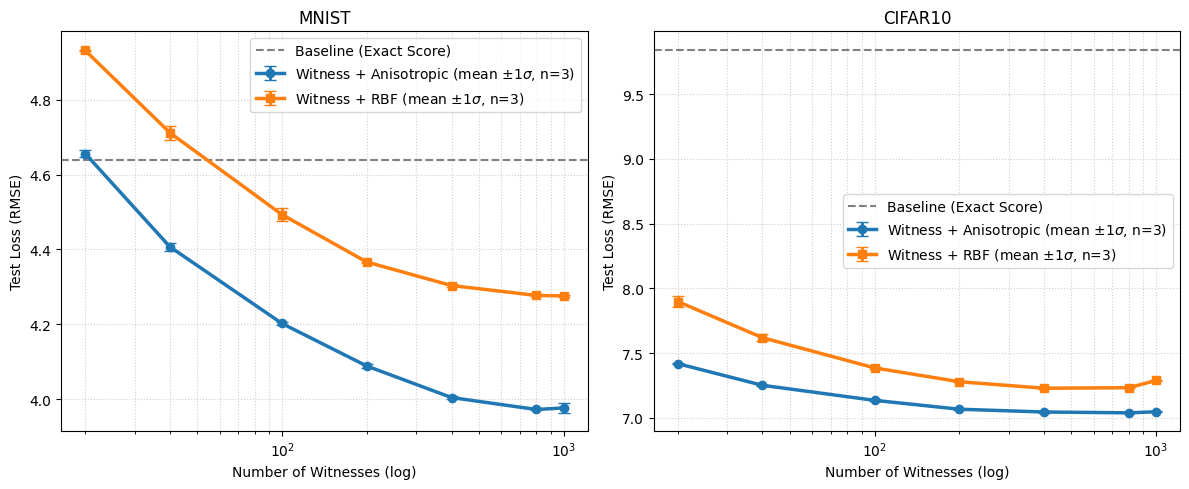

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_ds = ['mnist', 'cifar10']

for i, ds in enumerate(plot_ds):
    ax = axes[i]
    res = results[ds]
    
    # Aniso
    ax.errorbar(res['aniso']['k'], res['aniso']['rmse'], yerr=res['aniso']['rmse_err'],
        fmt='-o', capsize=4, elinewidth=2, linewidth=2.5, markersize=6,
        label=f'Witness + Anisotropic (mean $\pm$1$\sigma$, n={len(SEEDS)})')
    
    # RBF
    ax.errorbar(res['rbf']['k'], res['rbf']['rmse'], yerr=res['rbf']['rmse_err'],
        fmt='-s', capsize=4, elinewidth=2, linewidth=2.5, markersize=6,
        label=f'Witness + RBF (mean $\pm$1$\sigma$, n={len(SEEDS)})')
    
    # Baseline
    if res['base']['rmse']:
        ax.axhline(res['base']['rmse'], linestyle='--', color='gray', label='Baseline (Exact Score)')
        
    ax.set_xscale('log')
    ax.set_xlabel('Number of Witnesses (log)')
    ax.set_ylabel('Test Loss (RMSE)')
    ax.set_title(ds.upper())
    ax.grid(True, which='both', ls=':', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
if 'cifar100' in results:
    c100 = results['cifar100']
    print("\nTable 1: CIFAR-100 RMSE")
    data = []
    for idx, k in enumerate(c100['rbf']['k']):
        data.append({
            'K': k,
            'RBF': f"{c100['rbf']['rmse'][idx]:.3f} ± {c100['rbf']['rmse_err'][idx]:.3f}",
            'Aniso': f"{c100['aniso']['rmse'][idx]:.3f} ± {c100['aniso']['rmse_err'][idx]:.3f}"
        })
    display(pd.DataFrame(data))

print("\nTable 2: FID Scores")
fid_data = []
for ds in ['cifar10', 'cifar100']:
    if ds in results:
        res = results[ds]
        for idx, k in enumerate(res['rbf']['k']):
            r_fid = f"{res['rbf']['fid'][idx]:.1f}" if idx < len(res['rbf']['fid']) else "-"
            a_fid = f"{res['aniso']['fid'][idx]:.1f}" if idx < len(res['aniso']['fid']) else "-"
            fid_data.append({'Dataset': ds, 'K': k, 'RBF FID': r_fid, 'Aniso FID': a_fid})
display(pd.DataFrame(fid_data))


Table 1: CIFAR-100 RMSE


,K,RBF,Aniso
0,20,7.894 ± 0.003,7.441 ± 0.004
1,40,7.721 ± 0.003,7.267 ± 0.004
2,100,7.414 ± 0.005,7.126 ± 0.006
3,200,7.271 ± 0.003,7.059 ± 0.000
4,400,7.221 ± 0.002,7.032 ± 0.008
5,800,7.236 ± 0.004,7.020 ± 0.002
6,1000,7.270 ± 0.004,7.035 ± 0.003



Table 2: FID Scores


,Dataset,K,RBF FID,Aniso FID
0,cifar10,20,344.3,306.7
1,cifar10,40,361.5,239.5
2,cifar10,100,314.1,192.7
3,cifar10,200,268.2,173.5
4,cifar10,400,219.2,161.9
5,cifar10,800,240.4,168.5
6,cifar10,1000,271.3,168.6
7,cifar100,20,313.8,284.2
8,cifar100,40,338.6,221.4
9,cifar100,100,305.8,181.3


In [ ]:
print(f"\n{'='*40}\nSNR Analysis\n{'='*40}")
for ds in DATASETS:
    _, loader, _, _ = get_data(ds)
    total_img_std = 0.0
    count = 0
    for x, _ in loader:
        img_stds = x.std(dim=1, unbiased=False)
        total_img_std += img_stds.sum().item()
        count += x.size(0)
    avg_img_std = total_img_std / count
    snr = NOISE_STD / avg_img_std
    print(f"{ds.upper()}: Avg Img Std={avg_img_std:.4f} | SNR={snr:.4f}")


SNR Analysis
Loading mnist...
MNIST: Avg Img Std=0.3012 | SNR=3.3202
Loading cifar10...
Files already downloaded and verified


CIFAR10: Avg Img Std=0.2102 | SNR=4.7568
Loading cifar100...
Files already downloaded and verified
CIFAR100: Avg Img Std=0.2167 | SNR=4.6148



Generating Figure 1 Visualization


Files already downloaded and verified
Loading MNIST Aniso Model...
Loading CIFAR-10 Aniso Model...


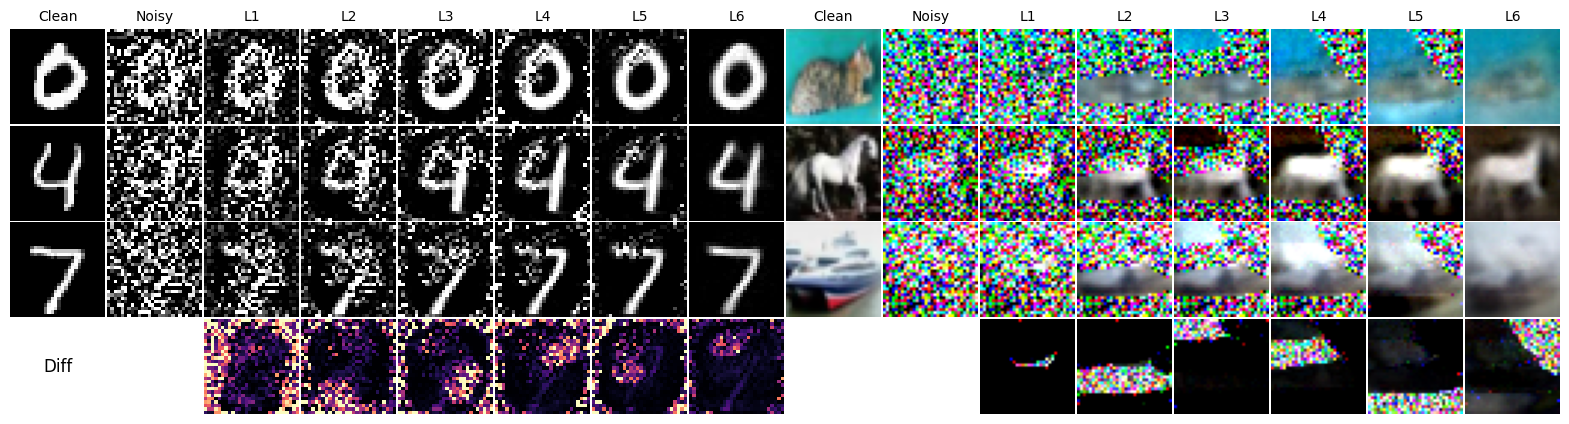

In [ ]:
#  Figure 1: Denoising Trajectory Visualization 
# This cell loads the K=1000 Anisotropic models trained above and generates
# the visual trajectory comparison.

print(f"\n{'='*40}\nGenerating Figure 1 Visualization\n{'='*40}")

# 1. Helpers from Figure 1
def find_nth_occurrence_index(dataset, target_label, n):
    count = -1
    for i, (_, label) in enumerate(dataset):
        if label == target_label:
            count += 1
            if count == n:
                return i
    raise ValueError(f"Label {target_label} not found {n} times")

def get_vis_dataset(name):
    # We load the standard test sets to match the specific indices (Cat, Horse, Ship)
    # used in the paper, rather than the random splits used in Fig 7 training.
    to_flat = T.Compose([T.ToTensor(), T.Lambda(lambda x: x.view(-1))])
    if name == 'mnist':
        ds = torchvision.datasets.MNIST(DATA_ROOT, train=False, download=True, transform=to_flat)
        shape = (1, 28, 28)
    else:
        ds = torchvision.datasets.CIFAR10(DATA_ROOT, train=False, download=True, transform=to_flat)
        shape = (3, 32, 32)
    return ds, shape

def plot_image(ax, img_tensor, shape, cmap=None):
    C, H, W = shape
    if C == 1:
        ax.imshow(img_tensor.view(H, W).clamp(0, 1), cmap=cmap or 'gray')
    else:
        ax.imshow(img_tensor.view(C, H, W).permute(1, 2, 0).clamp(0, 1), cmap=cmap)
    ax.axis('off')

@torch.no_grad()
def generate_trajectory_rows(model, dataset, indices, noise_std=1.0):
    rows = []
    diffs = []
    for idx in indices:
        clean_img = dataset[idx][0].to(device)
        noisy_img = clean_img + noise_std * torch.randn_like(clean_img)
        
        # Run inference (returns x, traj)
        _, trajectory = model(noisy_img.unsqueeze(0))
        
        # [Clean, Noisy, Step1...Step6]
        vis_sequence = [clean_img.cpu()] + [noisy_img.cpu()] + [t.squeeze().cpu() for t in trajectory[1:]]
        rows.append(vis_sequence)
        
        # Diffs between steps
        step_diffs = [torch.abs(trajectory[j] - trajectory[j-1]).squeeze().cpu() for j in range(1, 7)]
        diffs.append(step_diffs)
    return rows, step_diffs

# 2. Main Visualization Logic
def create_figure_1():
    # Define indices to match paper
    ds_m, shape_m = get_vis_dataset('mnist')
    idx_m = [find_nth_occurrence_index(ds_m, d, 0) for d in (0, 4, 7)]
    
    ds_c, shape_c = get_vis_dataset('cifar10')
    idx_c = [
        find_nth_occurrence_index(ds_c, 3, 16), # Cat
        find_nth_occurrence_index(ds_c, 7, 0),  # Horse
        find_nth_occurrence_index(ds_c, 8, 0)   # Ship
    ]

    # Load the K=1000 models trained in previous cells
    # We use the first seed (0)
    K_target = 1000
    seed_target = 0
    
    # Load MNIST Model
    print("Loading MNIST Aniso Model...")
    ep_m = EPOCHS['mnist']['aniso']
    path_m = MODEL_ROOT / 'mnist' / 'aniso' / f"witness_K{K_target}_ep{ep_m}_seed{seed_target}.pth"
    
    # FIX: Use torch.zeros(K_target, ...) so shape matches checkpoint weights (1000, D)
    model_m = SixStepDenoiserAniso(784, K_target, torch.zeros(K_target, 784), seed_offset=seed_target).to(device)
    model_m.load_state_dict(torch.load(path_m, map_location=device))
    model_m.eval()
    
    # Load CIFAR Model
    print("Loading CIFAR-10 Aniso Model...")
    ep_c = EPOCHS['cifar10']['aniso']
    path_c = MODEL_ROOT / 'cifar10' / 'aniso' / f"witness_K{K_target}_ep{ep_c}_seed{seed_target}.pth"
    
    # FIX: Use torch.zeros(K_target, ...) so shape matches checkpoint weights (1000, D)
    model_c = SixStepDenoiserAniso(3072, K_target, torch.zeros(K_target, 3072), seed_offset=seed_target).to(device)
    model_c.load_state_dict(torch.load(path_c, map_location=device))
    model_c.eval()

    # Generate Visualization Data
    rows_m, diff_m = generate_trajectory_rows(model_m, ds_m, idx_m)
    rows_c, diff_c = generate_trajectory_rows(model_c, ds_c, idx_c)

    # plotting
    n_rows = 3 
    n_cols = 8 # Clean + Noisy + 6 Steps
    total_cols = n_cols * 2 
    
    fig, axes = plt.subplots(n_rows + 1, total_cols, figsize=(20, 5), gridspec_kw=dict(wspace=0.02, hspace=0.02))
    column_titles = ['Clean', 'Noisy'] + [f'L{i}' for i in range(1, 7)]

    # Plot MNIST (Left)
    for r, row_imgs in enumerate(rows_m):
        for c, img in enumerate(row_imgs):
            ax = axes[r, c]
            plot_image(ax, img, shape_m)
            if r == 0: ax.set_title(column_titles[c], fontsize=10)

    # Plot CIFAR (Right)
    for r, row_imgs in enumerate(rows_c):
        for c, img in enumerate(row_imgs):
            ax = axes[r, c + n_cols]
            plot_image(ax, img, shape_c)
            if r == 0: ax.set_title(column_titles[c], fontsize=10)

    # Plot Differences (Bottom Row)
    axes[3, 0].text(0.5, 0.5, 'Diff', ha='center', va='center', fontsize=12); axes[3,0].axis('off')
    axes[3, 1].axis('off'); axes[3, n_cols].axis('off'); axes[3, n_cols+1].axis('off')
    
    for j, img in enumerate(diff_m):
        plot_image(axes[3, j + 2], img, shape_m, cmap='magma')
        
    for j, img in enumerate(diff_c):
        plot_image(axes[3, n_cols + j + 2], img, shape_c, cmap='magma')

    plt.show()

# Run
if 'cifar10' in results: # Only run if cifar10 was processed
    create_figure_1()
else:
    print("Skipping Figure 1: CIFAR-10 model not found in current run.")